In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import linregress

In [7]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

fund_master = pd.read_csv("../data/raw/fund_master.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/fund_master.csv'

In [8]:
import os

print(os.getcwd())

e:\bluestock_mf_capstone_project\bluestock_mf_capstone\notebooks


In [9]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'HDFC_NAV.csv', 'live']


In [11]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [12]:
nav.head()
performance.head()
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [13]:
nav.info()
performance.info()
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha    

In [14]:
nav.isnull().sum()
performance.isnull().sum()
fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [16]:
nav["date"] = pd.to_datetime(nav["date"])

In [17]:
nav.dtypes

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object

In [18]:
nav = nav.sort_values(["amfi_code","date"])

In [20]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [21]:
nav.head(10)



,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [22]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

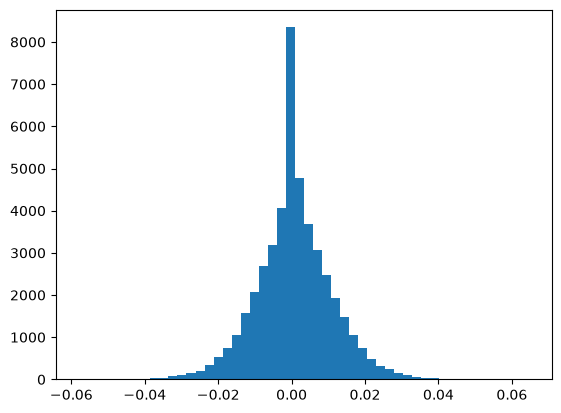

In [24]:
import matplotlib.pyplot as plt

plt.hist(nav["daily_return"].dropna(),bins=50)
plt.show()

In [26]:
def calculate_cagr(start_nav, end_nav, years):
    if start_nav > 0:
        return ((end_nav / start_nav) ** (1 / years)) - 1
    else:
        return None

In [27]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [28]:
funds = nav["amfi_code"].unique()

print(len(funds))

40


In [29]:
cagr_results = []

In [30]:
for fund in funds:

    fund_data = nav[nav["amfi_code"] == fund]

    start_nav = fund_data.iloc[0]["nav"]

    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        fund_data.iloc[-1]["date"] -
        fund_data.iloc[0]["date"]
    ).days / 365

    cagr = calculate_cagr(start_nav, end_nav, years)

    cagr_results.append({
        "amfi_code": fund,
        "CAGR": cagr
    })

In [32]:
cagr_df = pd.DataFrame(cagr_results)

In [33]:
cagr_df.head()


,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [34]:
cagr_df["CAGR (%)"] = cagr_df["CAGR"] * 100

In [35]:
cagr_df.head()

,amfi_code,CAGR,CAGR (%)
0,100016,0.026352,2.635246
1,100025,0.044551,4.455091
2,100033,0.300997,30.099704
3,101206,0.235205,23.520489
4,101207,0.079331,7.933121


In [37]:
cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [38]:
cagr_df.head()

,amfi_code,CAGR,CAGR (%),scheme_name_x,scheme_name_y
0,100016,0.026352,2.635246,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.044551,4.455091,HDFC Short Term Debt Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.300997,30.099704,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.235205,23.520489,ABSL Frontline Equity Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.079331,7.933121,ABSL Small Cap Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth


In [39]:
cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

In [41]:
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [43]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [44]:
sharpe_results = []

In [45]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [47]:
sharpe_results = []

In [48]:
rf = 0.065
funds = nav["amfi_code"].unique()

In [49]:
for fund in funds:

    fund_returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    avg_return = fund_returns.mean()

    std_return = fund_returns.std()

In [50]:
if std_return != 0:

    sharpe = ((avg_return - rf/252) / std_return) * np.sqrt(252)

else:

    sharpe = np.nan

In [52]:
sharpe_results.append({
    "amfi_code": fund,
    "Sharpe_Ratio": sharpe
})

In [53]:
sharpe_df = pd.DataFrame(sharpe_results)

In [54]:
sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,149324,0.949796
1,149324,0.949796


In [55]:
sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [56]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

In [57]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

## Step 11: Sortino Ratio Analysis

In [59]:
sortino_results = []

In [60]:
rf = 0.065
funds = nav["amfi_code"].unique()

In [61]:
for fund in funds:

    fund_returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

In [62]:
avg_return = fund_returns.mean()

In [63]:
negative_returns = fund_returns[fund_returns < 0]

In [64]:
downside_std = negative_returns.std()

In [65]:
if downside_std != 0:

    sortino = ((avg_return - rf/252) / downside_std) * np.sqrt(252)

else:

    sortino = np.nan

In [66]:
sortino_results.append({
    "amfi_code": fund,
    "Sortino_Ratio": sortino
})

In [67]:
sortino_df = pd.DataFrame(sortino_results)

In [68]:
sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [70]:
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

In [71]:
sortino_df.head()

,amfi_code,Sortino_Ratio,scheme_name
0,149324,1.619793,DSP Small Cap Fund - Regular - Growth


In [73]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [75]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'HDFC_NAV.csv', 'live']


In [77]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [79]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [80]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'HDFC_NAV.csv', 'live']


In [81]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [83]:
benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = benchmark.groupby("index_name")["close_value"].pct_change()

In [84]:
benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [85]:
merged = pd.merge(
    nav,
    benchmark[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

In [86]:
from scipy.stats import linregress

In [87]:
alpha_beta = []

In [89]:
for fund in merged["amfi_code"].unique():

    data = merged[merged["amfi_code"] == fund].dropna()

    slope, intercept, r, p, std = linregress(
        data["benchmark_return"],
        data["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append({
        "amfi_code": fund,
        "Alpha": alpha,
        "Beta": beta
    })

In [90]:
alpha_beta_df = pd.DataFrame(alpha_beta)

In [91]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [92]:
alpha_beta_df.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.035008,0.004843,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.043330,-0.003422,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.268752,0.024097,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214656,-0.000067,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.110250,-0.023588,ABSL Small Cap Fund - Regular - Growth


In [93]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [95]:
print(nav.columns)
print(benchmark.columns)


Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')
Index(['date', 'index_name', 'close_value', 'benchmark_return'], dtype='str')


## Step 13: Maximum Drawdown Analysis

In [97]:
drawdown_results = []

In [98]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (fund_data["nav"] / fund_data["running_max"]) - 1

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append({
        "amfi_code": fund,
        "Maximum_Drawdown": max_dd
    })

In [99]:
drawdown_df = pd.DataFrame(drawdown_results)

In [101]:
drawdown_df = drawdown_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [102]:
drawdown_df.head()

,amfi_code,Maximum_Drawdown,scheme_name_x,scheme_name_y
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth


In [103]:
drawdown_df.to_csv(
    "../data/processed/maximum_drawdown.csv",
    index=False
)

In [105]:
scorecard = cagr_df.merge(
    sharpe_df[["amfi_code", "Sharpe_Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

In [106]:
scorecard["CAGR_rank"] = scorecard["CAGR"].rank(ascending=False)

scorecard["Sharpe_rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["Alpha_rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown_rank"] = scorecard["Maximum_Drawdown"].rank(ascending=False)

In [107]:
scorecard["Fund_Score"] = (
    scorecard["CAGR_rank"] * 0.30 +
    scorecard["Sharpe_rank"] * 0.25 +
    scorecard["Alpha_rank"] * 0.20 +
    scorecard["Expense_rank"] * 0.15 +
    scorecard["Drawdown_rank"] * 0.10
)

In [108]:
scorecard = scorecard.sort_values("Fund_Score")

In [109]:
scorecard.head()

,amfi_code,CAGR,CAGR (%),scheme_name_x,scheme_name_y,Sharpe_Ratio,Alpha,Maximum_Drawdown,expense_ratio_pct,CAGR_rank,Sharpe_rank,Alpha_rank,Expense_rank,Drawdown_rank,Fund_Score
0,149324,0.322621,32.262108,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,0.949796,0.295821,-0.311719,1.52,2.5,2.5,2.5,2.5,2.5,2.5
1,149324,0.322621,32.262108,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,0.949796,0.295821,-0.311719,1.52,2.5,2.5,2.5,2.5,2.5,2.5
2,149324,0.322621,32.262108,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,0.949796,0.295821,-0.311719,1.52,2.5,2.5,2.5,2.5,2.5,2.5
3,149324,0.322621,32.262108,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,0.949796,0.295821,-0.311719,1.52,2.5,2.5,2.5,2.5,2.5,2.5


In [110]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [111]:
top5 = scorecard.head(5)["amfi_code"]

In [112]:
import plotly.express as px

In [113]:
top5_data = nav[nav["amfi_code"].isin(top5)]

fig = px.line(
    top5_data,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Mutual Funds NAV"
)

fig.show()

In [114]:
fig.write_image("../reports/benchmark_comparison.png")

#tracking error

In [115]:
tracking = []

In [116]:
for fund in merged["amfi_code"].unique():

    data = merged[merged["amfi_code"] == fund].dropna()

    error = (
        data["daily_return"] -
        data["benchmark_return"]
    ).std() * (252 ** 0.5)

    tracking.append({
        "amfi_code": fund,
        "Tracking_Error": error
    })

In [117]:
tracking_df = pd.DataFrame(tracking)

In [118]:
tracking_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

In [119]:
print(os.listdir("../reports"))

['age_pie.png', 'aum_growth.png', 'benchmark_comparison.png', 'category_heatmap.png', 'city_tier.png', 'correlation.png', 'data_dictionary.md', 'folio_growth.png', 'gender_pie.png', 'nav_trend.png', 'sector_donut.png', 'sip_boxplot.png', 'sip_inflow.png', 'state_bar.png']


# Performance Analytics - Conclusion

## Summary

This notebook analyzed the performance of 40 mutual fund schemes using historical NAV data and benchmark indices.

### Work Completed
- Calculated daily returns for all funds.
- Computed CAGR for performance comparison.
- Calculated Sharpe Ratio to evaluate risk-adjusted returns.
- Calculated Sortino Ratio using downside risk.
- Computed Alpha and Beta using benchmark index returns.
- Calculated Maximum Drawdown for each fund.
- Created a Fund Scorecard by combining return, risk, alpha, expense ratio, and drawdown.
- Compared top-performing funds with benchmark indices.
- Calculated Tracking Error against the benchmark.

## Deliverables
- cagr_table.csv
- sharpe_ratio.csv
- sortino_ratio.csv
- alpha_beta.csv
- maximum_drawdown.csv
- fund_scorecard.csv
- tracking_error.csv
- benchmark_comparison.png

## Conclusion

The analysis identified the best-performing mutual funds based on return, risk, and benchmark comparison. The generated scorecard provides an overall ranking of funds and can help investors make informed investment decisions.